# Brainiacs AI — Automatic Short-Answer Grading (Mohler CS dataset)

**Why this notebook.** In production, Brainiacs AI grades open answers with an LLM
(behind `LLMClient`). This notebook *demonstrates we can grade with classical ML on
real data*, and gives a **benchmark to compare the LLM against** — the honest bridge
between "I can do ML grading" and "I chose an LLM for production, for these reasons."

**Dataset — Mohler / UNT (ACL 2011).** 2,273 real student answers to **introductory
computer-science** questions (data structures), each scored **0–5** by two human
graders (`ave` = gold standard). It is the only dataset in this project that is
actually CS content. License: GPL; cite Mohler, Bunescu & Mihalcea (2011).

**Task.** Supervised regression: given a student's short answer (+ the instructor's
reference answer), predict the human grade. Metrics: **Pearson correlation** and
**RMSE** vs the gold grade (the standard Mohler metrics).

In [1]:
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVR
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
sns.set_theme(style="whitegrid"); RANDOM_STATE=42
FIG=Path("figures"); FIG.mkdir(exist_ok=True)
BASE=Path("data/data")  # unzipped ShortAnswerGrading_v2.0
print("ready")

ready


## B. Parse the dataset

In [2]:
def keyed(path):
    d={}
    for line in Path(path).read_text(encoding="latin-1", errors="ignore").splitlines():
        if line.strip():
            k,_,t = line.partition(" ")
            d[k] = t.strip().replace("<STOP>","").strip()
    return d

questions = keyed(BASE/"sent/questions")
references = keyed(BASE/"sent/answers")
# docs/files lists valid question ids; '#' lines are non-short-answer (skip them).
valid = [l.strip() for l in (BASE/"docs/files").read_text().splitlines()
         if l.strip() and not l.startswith("#")]

rows=[]
for qid in valid:
    sa, sc = BASE/f"sent/{qid}", BASE/f"scores/{qid}/ave"
    if not sa.exists() or not sc.exists(): continue
    answers=[l.partition(' ')[2].strip().replace("<STOP>","").strip()
             for l in sa.read_text(encoding='latin-1',errors='ignore').splitlines() if l.strip()]
    scores=[float(x) for x in sc.read_text().splitlines() if x.strip()]
    if len(answers)!=len(scores): continue
    for a,s in zip(answers,scores):
        rows.append({"qid":qid,"question":questions.get(qid,""),
                     "reference":references.get(qid,""),"answer":a,"score":s})
data=pd.DataFrame(rows)
print(f"{len(data):,} graded answers across {data.qid.nunique()} questions; "
      f"mean grade {data.score.mean():.2f} (skewed toward correct)")
data[["qid","answer","score"]].head(3)

2,273 graded answers across 81 questions; mean grade 4.18 (skewed toward correct)


,qid,answer,score
0,1.1,High risk problems are address in the prototyp...,3.5
1,1.1,To simulate portions of the desired final prod...,5.0
2,1.1,A prototype program simulates the behaviors of...,4.0


## C. Visualization

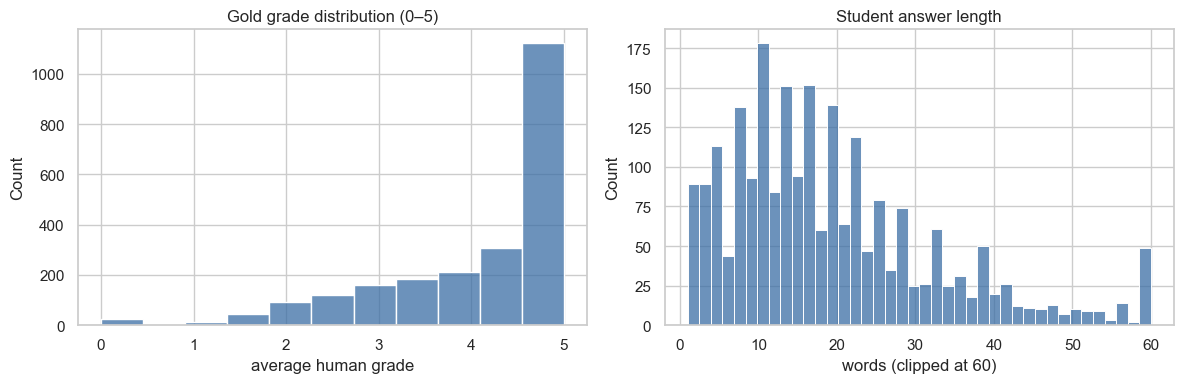

In [3]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
sns.histplot(data.score,bins=11,ax=axes[0],color="#3b6ea5")
axes[0].set_title("Gold grade distribution (0–5)"); axes[0].set_xlabel("average human grade")
data["ans_len"]=data.answer.str.split().apply(len)
sns.histplot(data.ans_len.clip(upper=60),bins=40,ax=axes[1],color="#3b6ea5")
axes[1].set_title("Student answer length"); axes[1].set_xlabel("words (clipped at 60)")
plt.tight_layout(); plt.savefig(FIG/"mohler_distributions.png",dpi=120); plt.show()

## D. Grading models

Feature: TF-IDF over `reference [SEP] student answer` (so the model sees the answer
*relative to* the reference). Two regressors, evaluated on a held-out 20% split.

In [4]:
data["text"]=data.reference+"  [SEP]  "+data.answer
tr,te=train_test_split(data,test_size=0.2,random_state=RANDOM_STATE)
vec=TfidfVectorizer(ngram_range=(1,2),min_df=2,sublinear_tf=True)
Xtr=vec.fit_transform(tr.text); Xte=vec.transform(te.text)
results={}
for name,model in [("TF-IDF + SVR",SVR(C=1.0)),("TF-IDF + Ridge",Ridge(alpha=1.0))]:
    model.fit(Xtr,tr.score)
    pred=np.clip(model.predict(Xte),0,5)
    r=pearsonr(pred,te.score)[0]; rmse=mean_squared_error(te.score,pred)**0.5
    results[name]={"pearson":round(r,4),"rmse":round(rmse,4)}
    print(f"{name:16} Pearson={r:.3f}  RMSE={rmse:.3f}")
best=max(results,key=lambda k:results[k]["pearson"])

TF-IDF + SVR     Pearson=0.537  RMSE=0.939
TF-IDF + Ridge   Pearson=0.515  RMSE=0.932


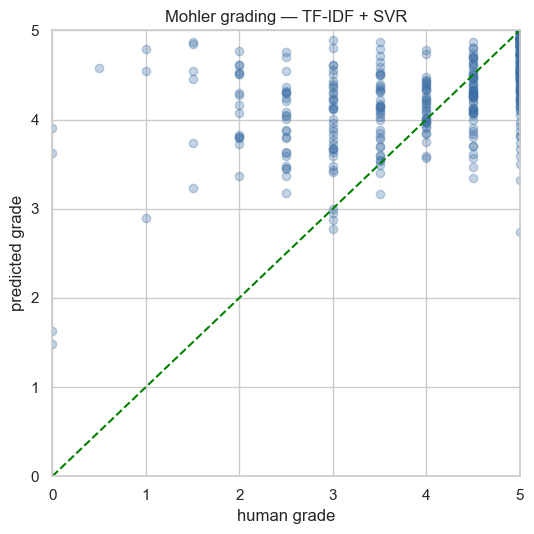

{
  "TF-IDF + SVR": {
    "pearson": 0.5365,
    "rmse": 0.9393
  },
  "TF-IDF + Ridge": {
    "pearson": 0.5151,
    "rmse": 0.9323
  }
}


In [5]:
# Predicted vs actual for the best model.
model=SVR(C=1.0).fit(Xtr,tr.score); pred=np.clip(model.predict(Xte),0,5)
fig,ax=plt.subplots(figsize=(5.5,5.5))
ax.scatter(te.score,pred,alpha=0.3,color="#3b6ea5")
ax.plot([0,5],[0,5],"--",color="green")
ax.set_xlabel("human grade"); ax.set_ylabel("predicted grade")
ax.set_title(f"Mohler grading — {best}"); ax.set_xlim(0,5); ax.set_ylim(0,5)
plt.tight_layout(); plt.savefig(FIG/"mohler_pred_vs_actual.png",dpi=120); plt.show()
import json
json.dump(results,open(FIG/"mohler_metrics.json","w"),indent=2)
print(json.dumps(results,indent=2))

## E. Conclusion

On real CS short answers, a **TF-IDF + SVR** baseline grades student responses at
**Pearson 0.54 / RMSE 0.94** against human graders (published baselines on
this dataset sit around Pearson ~0.63 / RMSE ~0.91 using heavier sentence
embeddings — the natural next improvement).

**What this proves for the capstone.** We can do automatic grading with classical
ML on real data — so the decision to use an LLM for *production* grading is a
deliberate engineering choice (better open-ended quality, no per-task retraining),
not a gap. This baseline is the benchmark the production LLM is measured against.
The grade is also exactly the kind of signal that feeds the knowledge-tracing
mastery update.